# For temporarily debugging and testing units

In [1]:
import torch
import torchvision
from theory import parse_kernel_fn, compute_W_var
from numpy.linalg import inv
import tqdm, data, theory, utils
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

P = 100
P_test = 105
n_tasks = 3
T = 0
sigma = 0.2
student_type = 'relu'
lamb = 100000
SEED = 0
n_epochs = 1
N0 = 100

fixed_w = False

np.random.seed(SEED)

def prepare_student_teacher_data():
    train_x, test_x = utils.generate_rotating_inputs(P, P_test, N0, n_tasks, resample=True, total_angle=0,
                                                     distance=0, only_test_last=False)
    train_Y, test_Y = utils.get_teacher_labels(train_x, test_x, max_scaler=1)
    # train_Y, test_Y = utils.get_linear_teacher_labels(train_x, test_x, max_scaler=teacher_speed)
    return train_x, test_x, train_Y, test_Y


# train_x, test_x, train_Y, test_Y = prepare_student_teacher_data()
seq_of_train_x, seq_of_test_x, seq_of_train_y_digit, seq_of_test_y_digit = \
    data.prepare_sequential_dataset(n_tasks, P, P_test, dataset_name='mnist', resample=True,
                                    permutation=0, data_path=None)
# these objects have shape num_tasks * P/P_test * dim

train_Y = data.digit_to_onehot(seq_of_train_y_digit)[:, :, 0]
train_x = seq_of_train_x
test_x = seq_of_test_x
# create multiple copies
# seq_of_train_x = seq_of_train_x * n_epochs
# seq_of_test_x = seq_of_test_x * n_epochs
# seq_of_train_y_digit = np.tile(seq_of_train_y_digit, (n_epochs, 1))
# seq_of_test_y_digit = np.tile(seq_of_test_y_digit, (n_epochs, 1))

In [35]:
xxx = train_x[0][:, :200]


def arccos_kernel_2l(x1, x2, var1, var2, covar):
    kappa = covar / np.sqrt(var1 * var2)
    assert 0 < kappa <= 1
    k1 = theory.arccos_kernel(x1, x2, var1, var2, covar)
    x1_norm = np.diag(theory.arccos_kernel(x1, x1, var1, var1, var1))
    x2_norm = np.diag(theory.arccos_kernel(x2, x2, var2, var2, var2))
    layer1_norm_mat = np.sqrt(x1_norm.reshape(-1, 1) @ x2_norm.reshape(1, -1))
    cos_theta1_eff = k1 / layer1_norm_mat * kappa
    cos_theta1_eff[cos_theta1_eff > 1] = 1
    theta1_eff = np.arccos(cos_theta1_eff)
    return 1 / 2 / np.pi * np.sqrt(var1 * var2) * layer1_norm_mat *\
        ((np.pi - theta1_eff) * cos_theta1_eff + np.sin(theta1_eff)), cos_theta1_eff / kappa

kk, first_layer_cos = arccos_kernel_2l(xxx, xxx, sigma**2, sigma**2 + 0.09, sigma**2)

/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:339: RuntimeWarning: invalid value encountered in true_divide
  cos_mat = x1 @ x2.T / norm_mat
/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:342: RuntimeWarning: invalid value encountered in cos
  core = ((np.pi - theta_eff) * np.cos(theta_eff) + np.sin(theta_eff)) * norm_mat
/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:342: RuntimeWarning: invalid value encountered in sin
  core = ((np.pi - theta_eff) * np.cos(theta_eff) + np.sin(theta_eff)) * norm_mat
/var/folders/10/xjpn2fl15qj92wt1kmhtn8bc0000gn/T/ipykernel_41432/1410951336.py:15: RuntimeWarning: invalid value encountered in sin
  ((np.pi - theta1_eff) * cos_theta1_eff + np.sin(theta1_eff)), cos_theta1_eff / kappa


In [36]:
N = 10000
N0 = 200

W11 = np.random.normal(0, sigma, (N0, N))
W21 = np.random.normal(W11, 0.3, (N0, N))
W12 = np.random.normal(0, sigma, (N, N))
W22 = np.random.normal(W12, 0.3, (N, N))

features10 = utils.relu(N0**-0.5 * xxx @ W11)
features1 = utils.relu(N**-0.5 * features10 @ W12)
features20 = utils.relu(N0**-0.5 * xxx @ W21)
features2 = utils.relu(N**-0.5 * features20 @ W22)

K = features1 @ features2.T / N

In [10]:
first_layer_cos_num = features10 @ features20.T /\
(np.linalg.norm(features10, axis=1).reshape(-1, 1) @ np.linalg.norm(features20, axis=1).reshape(1, -1))

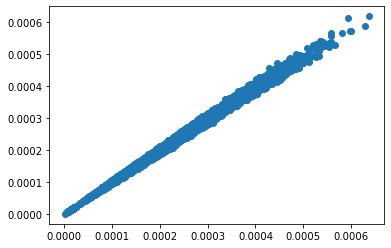

In [39]:
plt.figure()
plt.scatter(K.flatten(), kk.flatten())

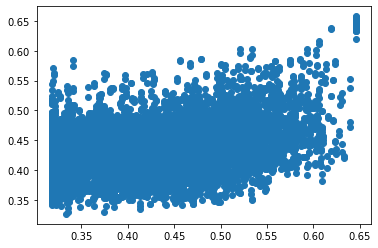

In [37]:
plt.figure()
plt.scatter(first_layer_cos.flatten(), first_layer_cos_num.flatten())

In [21]:
first_layer_cos

array([[1.        , 0.67360145, 0.6629774 , ..., 0.771341  , 0.71571964,
        0.65513885],
       [0.67360145, 1.        , 0.7109051 , ..., 0.72922593, 0.6775836 ,
        0.74413306],
       [0.6629774 , 0.7109051 , 1.        , ..., 0.71948975, 0.646788  ,
        0.7524013 ],
       ...,
       [0.771341  , 0.72922593, 0.71948975, ..., 1.        , 0.6771148 ,
        0.78246766],
       [0.71571964, 0.6775836 , 0.646788  , ..., 0.6771148 , 1.        ,
        0.6379376 ],
       [0.65513885, 0.74413306, 0.7524013 , ..., 0.78246766, 0.6379376 ,
        1.        ]], dtype=float32)

In [108]:
data.digit_to_onehot(seq_of_train_y_digit).shape

(3, 10, 1)

In [100]:


head_ind = 0
training_variances, test_variances, =\
theory.compute_predictor_variances(train_inputs=train_x,
                                w_var=sigma**2, P_test=P_test,
                                lambda_val=lamb,
                                test_inputs=test_x,
                                fix_weights=fixed_w, student_type=student_type)


training_predictions, test_predictions = theory.compute_mean_predictions(train_inputs=train_x,
                                        train_targets=train_Y,
                                        w_var=sigma**2, P_test=P_test,
                                        lambda_val=lamb,
                                        test_inputs=test_x,
                                        fix_weights=fixed_w, disable_tqdm=True, student_type=student_type)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 10 is different from 100)

In [93]:
# compare variances obtained from sampling

N = 3000
n_samples = 500
all_a_samples = np.zeros((n_tasks, N, n_samples))



W1 = np.random.normal(0, sigma, (N0, N))
W2 = np.random.normal(lamb / (lamb + sigma ** -2) * W1, np.sqrt((lamb + sigma ** -2) ** -1), (N0, N))
W3 = np.random.normal(lamb / (lamb + sigma ** -2) * W2, np.sqrt((lamb + sigma ** -2) ** -1), (N0, N))
Ws = [W1, W2, W3]

all_a_samples[0] = theory.sample_at(last_a=None, num_samples=n_samples, target_t=train_Y[0],
                                    features_t=utils.relu(N0**-0.5 * train_x[0] @ Ws[0]), temp=0, lambda_t=lamb, std_t=sigma)[0]

for i in range(1, n_tasks):
    all_a_samples[i] = theory.sample_at(last_a=all_a_samples[i-1], num_samples=n_samples, target_t=train_Y[i],
                                    features_t=utils.relu(N0**-0.5 * train_x[i] @ Ws[i]), temp=0, lambda_t=lamb, std_t=sigma)[0]


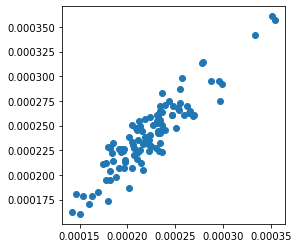

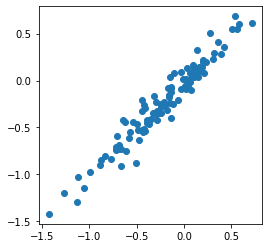

In [95]:
task_ind = 1
time_ind = 2

all_predictions = np.zeros((n_samples, P_test))
for i in range(n_samples):
    all_predictions[i] = utils.forward(test_x[task_ind], Ws[task_ind], all_a_samples[time_ind, :, i].reshape(-1, 1)).flatten()

prediction_vars = all_predictions.std(0)**2
theory_prediction_vars = np.diag(test_variances[task_ind, time_ind])

plt.figure(figsize=(4, 4))
plt.scatter(prediction_vars, theory_prediction_vars)

plt.figure(figsize=(4, 4))
plt.scatter(test_predictions[task_ind, time_ind], all_predictions.mean(0))